# Фазово-эквивариантный spline-memory DPD: BlackBoxData и OpenDPD

Этот ноутбук — самодостаточная воспроизводимая демонстрация нашего
цифрового предыскажителя (DPD). Весь вычислительный тракт ниже написан
прямо в ноутбуке: загрузка I/Q, модель PA, обучение DPD, метрики,
графики и тесты.

Основной эксперимент использует новый `BlackBoxData.mat`, подготовленный
в проекте как хронологические CSV-срезы. Измеренный `y_val` используется
для обучения вспомогательной модели PA и для диагностики её точности;
в правильной DPD-проверке входом остаётся только желаемый сигнал `x_val`:

```text
x_desired → DPD → frozen PA evaluator → y_hat ≈ g·x_desired
```

В конце приведён отдельный справочный блок с официальными результатами
OpenDPD на `APA_200MHz`. Это не объявляется прямым соревнованием: там
другой захват, другой PA-evaluator и другие определения EVM/ACLR.

## 1. Постановка и границы утверждений

Комплексный отсчёт основной полосы имеет вид

$$
x[n] = I[n] + jQ[n].
$$

Реальный PA реализует нелинейный оператор `F`. Мы хотим найти такой
предыскажатель `D`, чтобы

$$
F(D(x[n])) \approx g\,x[n].
$$

В этом ноутбуке `F` — зафиксированная GMP-модель, обученная на train-срезе.
Поэтому результат является **surrogate-only**: он показывает численную
работоспособность метода на данном evaluator, но ещё не измерение через
физический усилитель.

В файле `BlackBoxData.mat` отсутствуют частота дискретизации и границы
RF-полос. Поэтому мы строим нормированный PSD в циклах на отсчёт, но не
называем его ACLR и не делаем вывод о требованиях Huawei.

In [1]:
# Базовые импорты и настройки воспроизводимости.
from __future__ import annotations

import base64
import io
import hashlib
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
print("NumPy:", np.__version__)

NumPy: 2.5.1


In [2]:
# Встроенные train/validation массивы BlackBoxData (сжатый NPZ, base64).
# Генератор notebook подставляет payload перед сохранением файла.
EMBEDDED_DATA_B64 = """..."""


def load_embedded_splits() -> dict[str, np.ndarray]:
    """Decode the portable train/validation payload from this notebook.

    Returns:
        A dictionary with raw complex ``train_x``, ``train_y``,
        ``val_x`` and ``val_y`` arrays plus a human-readable source.
    """
    binary = base64.b64decode(EMBEDDED_DATA_B64.encode("ascii"))
    with np.load(io.BytesIO(binary), allow_pickle=False) as payload:
        result = {name: np.asarray(payload[name], dtype=np.complex128) for name in (
            "train_x_raw", "train_y_raw", "val_x_raw", "val_y_raw"
        )}
    result["source"] = "embedded BlackBoxData train/validation payload"
    return result


print("embedded payload ready; source data are portable with this notebook")

embedded payload ready; source data are portable with this notebook


## 2. Данные и хронологическое разбиение

Используются только публичные для селектора части подготовленного
набора: 92 000 отсчётов train и 23 000 отсчётов validation. Sealed test
в этом ноутбуке не открывается и не участвует в выборе архитектуры.

По умолчанию код ищет `data/private/blackbox_v3/selection` относительно
корня проекта. Если CSV недоступны, можно указать путь к исходному MAT
в `MAT_PATH`; тогда будут использованы переменные `x`, `y`, `eRef` и те
же границы `[5000:97000]`, `[97000:120000]`.

In [3]:
# Фиксированные параметры запуска. В portable-режиме менять пути не нужно:
# данные уже находятся внутри notebook.
PROJECT_CANDIDATES = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (p for p in PROJECT_CANDIDATES
     if (p / "data/private/blackbox_v3/selection").is_dir()),
    Path.cwd(),
)
SELECTION_DIR = PROJECT_ROOT / "data/private/blackbox_v3/selection"
USE_EMBEDDED_DATA = True
MAT_PATH = None  # optional external fallback, not needed for a portable run
OPENDPD_JSON = PROJECT_ROOT / "vendor/OpenDPD/benchmark/results/benchmark_report_results.json"
print("external project data directory detected =", SELECTION_DIR.is_dir())
print("USE_EMBEDDED_DATA =", USE_EMBEDDED_DATA)

external project data directory detected = True
USE_EMBEDDED_DATA = True


In [4]:
def read_iq_csv(path: Path) -> np.ndarray:
    """Read a two-column ``I,Q`` CSV and return ``I + jQ`` samples.

    Args:
        path: CSV file with a header and two numeric columns.

    Returns:
        One-dimensional finite complex128 vector.
    """
    raw = np.loadtxt(path, delimiter=",", skiprows=1)
    if raw.ndim != 2 or raw.shape[1] < 2:
        raise ValueError(f"Expected I,Q columns in {path}")
    signal = np.asarray(raw[:, 0] + 1j * raw[:, 1], dtype=np.complex128)
    if not np.all(np.isfinite(signal)):
        raise ValueError(f"Non-finite samples in {path}")
    return signal


def load_mat_splits(path: Path) -> dict[str, np.ndarray]:
    """Load the optional MAT fallback and apply the frozen split.

    The source variables are validated, while ``eRef`` is retained only
    for the shape check and is intentionally not used by the model.
    """
    from scipy.io import loadmat

    payload = loadmat(path)
    vectors = {}
    for name in ("x", "y", "eRef"):
        if name not in payload:
            raise ValueError(f"MAT file lacks {name}")
        value = np.asarray(payload[name]).reshape(-1)
        if not np.iscomplexobj(value):
            raise ValueError(f"MAT variable {name} is not complex")
        vectors[name] = np.asarray(value, dtype=np.complex128)
    if len({v.size for v in vectors.values()}) != 1:
        raise ValueError("x, y and eRef must have equal lengths")
    return {
        "train_x_raw": vectors["x"][5000:97000],
        "train_y_raw": vectors["y"][5000:97000],
        "val_x_raw": vectors["x"][97000:120000],
        "val_y_raw": vectors["y"][97000:120000],
        "source": path,
    }


def load_blackbox_splits(selection_dir: Path, mat_path: Path | None) -> dict[str, np.ndarray]:
    """Select embedded data first, then optional CSV/MAT fallbacks.

    The embedded branch is the default so that the notebook remains
    runnable when it is uploaded as a single file to Colab.
    """
    if USE_EMBEDDED_DATA:
        return load_embedded_splits()
    files = {
        "train_x_raw": selection_dir / "train_input.csv",
        "train_y_raw": selection_dir / "train_output.csv",
        "val_x_raw": selection_dir / "val_input.csv",
        "val_y_raw": selection_dir / "val_output.csv",
    }
    if all(path.is_file() for path in files.values()):
        result = {name: read_iq_csv(path) for name, path in files.items()}
        result["source"] = selection_dir
        return result
    if mat_path is not None and Path(mat_path).is_file():
        return load_mat_splits(mat_path)
    raise FileNotFoundError(
        "Не найдены подготовленные CSV и исходный MAT. "
        "Измените SELECTION_DIR или MAT_PATH."
    )


raw = load_blackbox_splits(SELECTION_DIR, MAT_PATH)
train_x_raw, train_y_raw = raw["train_x_raw"], raw["train_y_raw"]
val_x_raw, val_y_raw = raw["val_x_raw"], raw["val_y_raw"]
assert train_x_raw.size == train_y_raw.size == 92000
assert val_x_raw.size == val_y_raw.size == 23000
print("source:", raw["source"])
print("train:", train_x_raw.shape, "validation:", val_x_raw.shape)
print("raw train input peak:", np.max(np.abs(train_x_raw)))

source: embedded BlackBoxData train/validation payload
train: (92000,) validation: (23000,)
raw train input peak: 18336.09364068585


In [5]:
# Нормировка: общий scale вычисляется только по train input и применяется
# ко всем четырём массивам. Validation не влияет на масштаб.
TRAIN_INPUT_PEAK = float(np.max(np.abs(train_x_raw)))
train_x = train_x_raw / TRAIN_INPUT_PEAK
train_y = train_y_raw / TRAIN_INPUT_PEAK
val_x = val_x_raw / TRAIN_INPUT_PEAK
val_y = val_y_raw / TRAIN_INPUT_PEAK

# Целевой комплексный gain оценивается также только по train.
gain = np.vdot(train_x, train_y) / np.vdot(train_x, train_x)
print(f"train-only scale = {TRAIN_INPUT_PEAK:.6f}")
print(f"train-only complex gain = {gain.real:.8f} {gain.imag:+.8f}j")
print("normalized peaks:", *(f"{np.max(np.abs(v)):.6f}" for v in (train_x, train_y, val_x, val_y)))

# Единый causal warm-up для всех каскадных метрик и графиков.
# Они задаются здесь, до любого fit, поэтому не зависят от ячейки summary.
PA_WARMUP = 9
DPD_WARMUP = 2
CASCADE_WARMUP = PA_WARMUP + DPD_WARMUP
ideal_val = gain * val_x

train-only scale = 18336.093641
train-only complex gain = 0.99962078 +0.00067656j
normalized peaks: 1.000000 1.093883 0.971956 1.085530


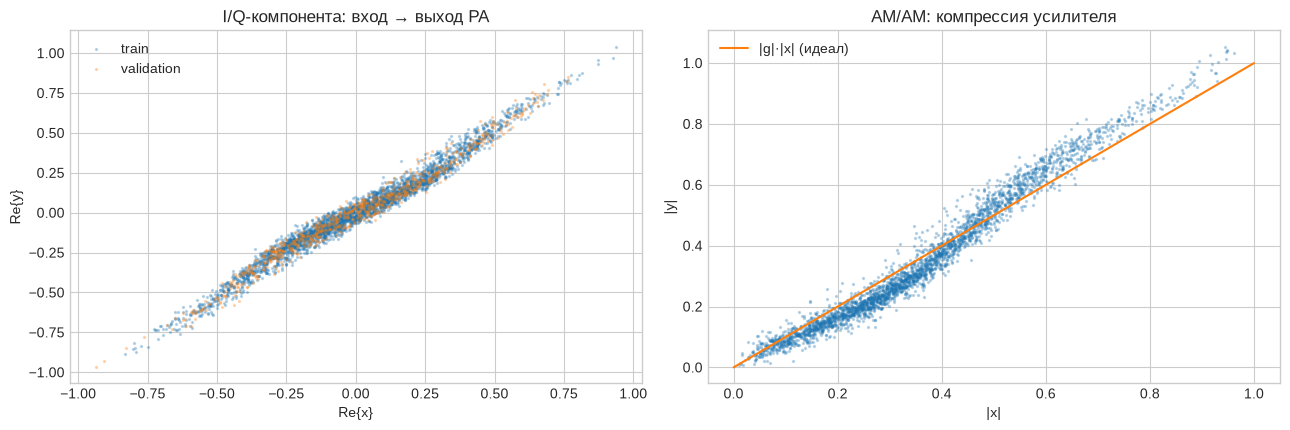

In [6]:
# Наглядная проверка входа/выхода PA.
sample = slice(None, None, 30)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].scatter(train_x.real[sample], train_y.real[sample], s=2, alpha=0.25, label="train")
axes[0].scatter(val_x.real[sample], val_y.real[sample], s=2, alpha=0.25, label="validation")
axes[0].set(xlabel="Re{x}", ylabel="Re{y}", title="I/Q-компонента: вход → выход PA")
axes[0].legend()
axes[1].scatter(np.abs(train_x)[sample], np.abs(train_y)[sample], s=2, alpha=0.25)
r = np.linspace(0, max(np.max(np.abs(train_x)), np.max(np.abs(val_x))), 200)
axes[1].plot(r, abs(gain) * r, color="tab:orange", label="|g|·|x| (идеал)")
axes[1].set(xlabel="|x|", ylabel="|y|", title="AM/AM: компрессия усилителя")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Метрики

Для основной оценки используем pooled complex NMSE:

$$
\mathrm{NMSE}_{dB} = 10\log_{10}
\frac{\mathbb{E}|\hat y[n]-y_\mathrm{ref}[n]|^2}
     {\mathbb{E}|y_\mathrm{ref}[n]|^2}.
$$

Чем меньше (более отрицательно) NMSE, тем лучше. Первые отсчёты после
сброса причинного состояния исключаются из оценки. RMS-EVM ниже — это
дополнительная временная диагностика, а не специфическая метрика OpenDPD.

In [7]:
def pooled_nmse_db(estimate: np.ndarray, reference: np.ndarray, warmup: int = 0) -> float:
    """Return pooled complex NMSE in dB after a causal warm-up.

    Args:
        estimate: Predicted complex output.
        reference: Desired/reference complex output.
        warmup: Number of record-start samples excluded from scoring.

    Returns:
        ``10*log10(MSE / reference_power)``.
    """
    estimate = np.asarray(estimate, dtype=np.complex128)
    reference = np.asarray(reference, dtype=np.complex128)
    if estimate.shape != reference.shape or estimate.ndim != 1:
        raise ValueError("metric vectors must be equal 1-D arrays")
    e = estimate[warmup:] - reference[warmup:]
    ref = reference[warmup:]
    return float(10.0 * np.log10(np.mean(np.abs(e) ** 2) / np.mean(np.abs(ref) ** 2)))


def rms_evm_db(estimate: np.ndarray, reference: np.ndarray, warmup: int = 0) -> float:
    """Return the time-domain RMS error-to-reference ratio in dB."""
    e = np.asarray(estimate)[warmup:] - np.asarray(reference)[warmup:]
    ref = np.asarray(reference)[warmup:]
    return float(20.0 * np.log10(np.sqrt(np.mean(np.abs(e) ** 2)) / np.sqrt(np.mean(np.abs(ref) ** 2))))


def summary(signal: np.ndarray) -> dict[str, float]:
    """Summarize RMS amplitude, peak amplitude and PAPR of a signal."""
    power = float(np.mean(np.abs(signal) ** 2))
    peak = float(np.max(np.abs(signal)))
    return {
        "rms": float(np.sqrt(power)),
        "peak": peak,
        "papr_db": float(10.0 * np.log10(peak * peak / power)),
    }


def metric_row(name: str, estimate: np.ndarray, reference: np.ndarray, warmup: int) -> dict:
    """Build one readable report row from the common metric functions."""
    return {
        "name": name,
        "nmse_db": pooled_nmse_db(estimate, reference, warmup),
        "evm_db": rms_evm_db(estimate, reference, warmup),
        **summary(estimate),
    }

## 4. Frozen GMP-модель PA

Для evaluator используем causal generalized memory polynomial:

$$
\begin{aligned}
\hat y[n] ={}&\sum_{k,q}a_{kq}x[n-q]|x[n-q]|^k\\
&+\sum_{k,q,l}b_{kql}x[n-q]|x[n-q-l]|^k\\
&+\sum_{k,q,l}c_{kql}x[n-q]|x[n-q+l]|^k.
\end{aligned}
$$

Последняя группа ограничена условием `lead ≤ signal_delay`, поэтому
в ноутбуке нет look-ahead. Коэффициенты находятся комплексной ridge-
регрессией на train; после этого PA больше не дообучается.

In [8]:
def causal_delay(signal: np.ndarray, delay: int) -> np.ndarray:
    """Apply a causal integer delay with zero padding at record start."""
    out = np.zeros_like(signal, dtype=np.complex128)
    if delay == 0:
        out[:] = signal
    elif delay > 0:
        out[delay:] = signal[:-delay]
    return out


def gmp_terms(ka=9, la=9, kb=3, lb=7, mb=3, kc=3, lc=7, mc=3):
    """Enumerate causal GMP terms as ``(branch, order, q, envelope_q)``."""
    terms = []
    for exponent in range(ka):
        for q in range(la):
            terms.append(("aligned", exponent, q, q))
    for exponent in range(1, kb + 1):
        for q in range(lb):
            for lag in range(1, mb + 1):
                terms.append(("lagging", exponent, q, q + lag))
    for exponent in range(1, kc + 1):
        for q in range(lc):
            for lead in range(1, mc + 1):
                if lead <= q:  # causal-leading policy
                    terms.append(("leading", exponent, q, q - lead))
    return tuple(terms)


def gmp_design(signal: np.ndarray, terms: tuple) -> np.ndarray:
    """Construct the dense complex GMP design matrix in term order."""
    signal = np.asarray(signal, dtype=np.complex128)
    columns = []
    for _branch, exponent, signal_delay, envelope_delay in terms:
        delayed = causal_delay(signal, signal_delay)
        if exponent == 0:
            columns.append(delayed)
        else:
            envelope = np.abs(causal_delay(signal, envelope_delay))
            columns.append(delayed * envelope ** exponent)
    return np.column_stack(columns)


def fit_complex_ridge(design: np.ndarray, target: np.ndarray, ridge: float) -> np.ndarray:
    """Fit complex coefficients with column scaling and ridge regularization.

    The data term is normalized by the number of samples, matching the
    frozen PA-selection protocol used for the BlackBox experiment.
    """
    design = np.asarray(design, dtype=np.complex128)
    target = np.asarray(target, dtype=np.complex128)
    column_rms = np.sqrt(np.mean(np.abs(design) ** 2, axis=0))
    if np.any(column_rms <= 0) or not np.all(np.isfinite(column_rms)):
        raise ValueError("invalid design column scale")
    # The project protocol minimizes mean squared error + ridge:
    # ||D c - q||²/N + ridge*||c||².  Dividing both data and target
    # by sqrt(N) is therefore part of the definition, not cosmetic
    # numerical scaling.
    normalization = np.sqrt(float(design.shape[0]))
    scaled = design / column_rms / normalization
    normalized_target = target / normalization
    if ridge > 0:
        regularizer = np.sqrt(ridge) * np.eye(
            scaled.shape[1], dtype=np.complex128
        )
        augmented = np.vstack((scaled, regularizer))
        augmented_target = np.concatenate(
            (normalized_target, np.zeros(scaled.shape[1], dtype=np.complex128))
        )
    else:
        augmented, augmented_target = scaled, normalized_target
    coeff_scaled = np.linalg.lstsq(augmented, augmented_target, rcond=None)[0]
    return coeff_scaled / column_rms


# Frozen evaluator configuration selected on the BlackBox validation split.
# The PA is auxiliary: its complexity is not the deployment DPD budget.
pa_terms = gmp_terms()
assert len(pa_terms) == 189
# Forward identification: measured PA input x -> measured output y.
started = time.perf_counter()
pa_design = gmp_design(train_x, pa_terms)
pa_coefficients = fit_complex_ridge(pa_design, train_y, ridge=1e-10)
pa_fit_seconds = time.perf_counter() - started
del pa_design
pa_train_hat = gmp_design(train_x, pa_terms) @ pa_coefficients
pa_val_design = gmp_design(val_x, pa_terms)
pa_val_hat = pa_val_design @ pa_coefficients
del pa_val_design
print(f"GMP terms: {len(pa_terms)} complex coefficients")
print(f"fit time: {pa_fit_seconds:.2f} s")
print(f"PA validation fidelity: {pooled_nmse_db(pa_val_hat, val_y, warmup=11):.3f} dB NMSE")

GMP terms: 189 complex coefficients
fit time: 5.99 s
PA validation fidelity: -28.590 dB NMSE


In [9]:
# До DPD: каскад frozen PA на желаемом validation input.
measured_no_dpd = metric_row("measured y (diagnostic)", val_y, ideal_val, CASCADE_WARMUP)
surrogate_no_dpd = metric_row("frozen PA, no DPD", pa_val_hat, ideal_val, CASCADE_WARMUP)
print(measured_no_dpd)
print(surrogate_no_dpd)

{'name': 'measured y (diagnostic)', 'nmse_db': -15.78064467142287, 'evm_db': -15.78064467142287, 'rms': 0.4096629648882422, 'peak': 1.0855304876366918, 'papr_db': 8.464306429911977}
{'name': 'frozen PA, no DPD', 'nmse_db': -16.010350840472285, 'evm_db': -16.010350840472285, 'rms': 0.4094811906023182, 'peak': 1.0540003577118497, 'papr_db': 8.212136018077079}


## 5. Наша spline-memory DPD

DPD имеет три causal-ветви:

$$
z[n] = \sum_{m\in\{0,1,2\}} x[n-m],C_m(|x[n-m]|).
$$

Каждая комплексная функция `C_m(r)` — кусочно-линейный сплайн с общими
квантильными узлами `r_0,…,r_{K-1}`:

$$
C_m(r)=(1-\alpha)C_{m,k}+\alpha C_{m,k+1},
\qquad
\alpha=\frac{r-r_k}{r_{k+1}-r_k}.
$$

На каждом отсчёте активны только два соседних коэффициента. Благодаря
множителю `x[n−m]` сохраняется фазовая эквивариантность:

$$
D(xe^{j\varphi})=D(x)e^{j\varphi}.
$$

Калибровка ILA — только способ получить коэффициенты:

$$
u[n]=y[n]/g,\qquad
\min_C\|\Phi(u)C-x\|_2^2+\lambda\|C\|_2^2.
$$

На validation/test deployment-вход меняется на `x_desired`; measured
`y_val` не подаётся внутрь DPD.

In [10]:
def make_quantile_knots(signal: np.ndarray, count: int) -> np.ndarray:
    """Place strictly increasing interpolation knots by amplitude quantiles."""
    radius = np.abs(np.asarray(signal, dtype=np.complex128))
    unit = np.linspace(0.0, 1.0, count)
    knots = np.quantile(radius, unit)
    knots[0] = 0.0
    knots[-1] = np.max(radius)
    knots = np.unique(knots)
    if knots.size < 2 or np.any(np.diff(knots) <= 0):
        raise ValueError("quantile knots are not strictly increasing")
    return knots


def spline_coordinates(radius: np.ndarray, knots: np.ndarray):
    """Return left-knot indices and local linear interpolation weights."""
    clipped = np.clip(np.asarray(radius, dtype=float), knots[0], knots[-1])
    left = np.searchsorted(knots, clipped, side="right") - 1
    left = np.clip(left, 0, knots.size - 2)
    weight = (clipped - knots[left]) / (knots[left + 1] - knots[left])
    return left.astype(np.int64), weight


def spline_memory_design(signal: np.ndarray, knots: np.ndarray, branches: tuple[tuple[int, int], ...]) -> np.ndarray:
    """Build ``Phi[n,bK+k] = x[n-m] B_k(|x[n-d]|)`` for spline-memory DPD."""
    signal = np.asarray(signal, dtype=np.complex128)
    columns = []
    for signal_delay, envelope_delay in branches:
        delayed_signal = causal_delay(signal, signal_delay)
        delayed_envelope = causal_delay(signal, envelope_delay)
        left, weight = spline_coordinates(np.abs(delayed_envelope), knots)
        basis = np.zeros((signal.size, knots.size), dtype=float)
        rows = np.arange(signal.size)
        basis[rows, left] = 1.0 - weight
        basis[rows, left + 1] += weight
        columns.extend((delayed_signal[:, None] * basis).T)
    return np.column_stack(columns)


def fit_spline_memory_dpd(calibration_input, target, knots, branches, ridge):
    """Fit the ILA spline-memory coefficients on the causal steady region."""
    warmup = max(max(b) for b in branches)
    design = spline_memory_design(calibration_input, knots, branches)[warmup:]
    # The frozen project protocol intentionally uses the raw spline
    # dictionary here (no column scaling), with the same normalized
    # objective and ridge as factorize_spline_group().
    normalization = np.sqrt(float(design.shape[0]))
    solve_design = design / normalization
    solve_target = target[warmup:] / normalization
    augmented = np.vstack(
        (solve_design, np.sqrt(ridge) * np.eye(design.shape[1], dtype=np.complex128))
    )
    augmented_target = np.concatenate(
        (solve_target, np.zeros(design.shape[1], dtype=np.complex128))
    )
    flat = np.linalg.lstsq(augmented, augmented_target, rcond=None)[0]
    return flat.reshape(len(branches), knots.size), warmup


def predict_spline_memory(signal, knots, branches, coefficients):
    """Evaluate the causal spline-memory DPD for one independent record."""
    signal = np.asarray(signal, dtype=np.complex128)
    output = np.zeros(signal.size, dtype=np.complex128)
    for branch_index, (signal_delay, envelope_delay) in enumerate(branches):
        delayed_signal = causal_delay(signal, signal_delay)
        delayed_envelope = causal_delay(signal, envelope_delay)
        left, weight = spline_coordinates(np.abs(delayed_envelope), knots)
        c = coefficients[branch_index]
        correction = c[left] + weight * (c[left + 1] - c[left])
        output += delayed_signal * correction
    return output

In [11]:
# Selected deployment candidate: three aligned memory branches,
_required = ("train_x", "train_y", "val_x", "gain", "pa_terms", "pa_coefficients", "pa_val_hat", "ideal_val", "CASCADE_WARMUP")
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Сначала выполните notebook сверху (Colab: Среда выполнения → Выполнить все). "
        "Для обучения DPD отсутствуют: " + ", ".join(_missing)
    )

# shared quantile knots and a small ridge for numerical stability.
branches = ((0, 0), (1, 1), (2, 2))
knot_count = 24
ridge = 1e-4
print("DPD configuration:", {"branches": branches, "knot_count": knot_count, "ridge": ridge})
# ILA calibration sees y/g, but deployment below receives desired x.
ila_input = train_y / gain
knots = make_quantile_knots(ila_input, knot_count)
dpd_coefficients, dpd_fit_warmup = fit_spline_memory_dpd(
    ila_input, train_x, knots, branches, ridge
)
predistorted_val = predict_spline_memory(val_x, knots, branches, dpd_coefficients)
cascade_dpd = gmp_design(predistorted_val, pa_terms) @ pa_coefficients
dpd_metrics = metric_row("selected spline-memory DPD", cascade_dpd, ideal_val, CASCADE_WARMUP)
no_dpd_mse = np.mean(np.abs(pa_val_hat[CASCADE_WARMUP:] - ideal_val[CASCADE_WARMUP:]) ** 2)
dpd_mse = np.mean(np.abs(cascade_dpd[CASCADE_WARMUP:] - ideal_val[CASCADE_WARMUP:]) ** 2)
improvement_db = float(10 * np.log10(no_dpd_mse / dpd_mse))
print("branches:", branches, "knots:", knots.size, "ridge:", ridge)
print("coefficients:", dpd_coefficients.shape, "fit warmup:", dpd_fit_warmup)
print(dpd_metrics)
print(f"improvement over frozen-PA no-DPD: {improvement_db:.3f} dB")

DPD configuration: {'branches': ((0, 0), (1, 1), (2, 2)), 'knot_count': 24, 'ridge': 0.0001}


branches: ((0, 0), (1, 1), (2, 2)) knots: 24 ridge: 0.0001
coefficients: (3, 24) fit warmup: 2
{'name': 'selected spline-memory DPD', 'nmse_db': -17.192240437598432, 'evm_db': -17.192240437598436, 'rms': 0.40311098016628877, 'peak': 1.0222165981698976, 'papr_db': 8.082366012561241}
improvement over frozen-PA no-DPD: 1.182 dB


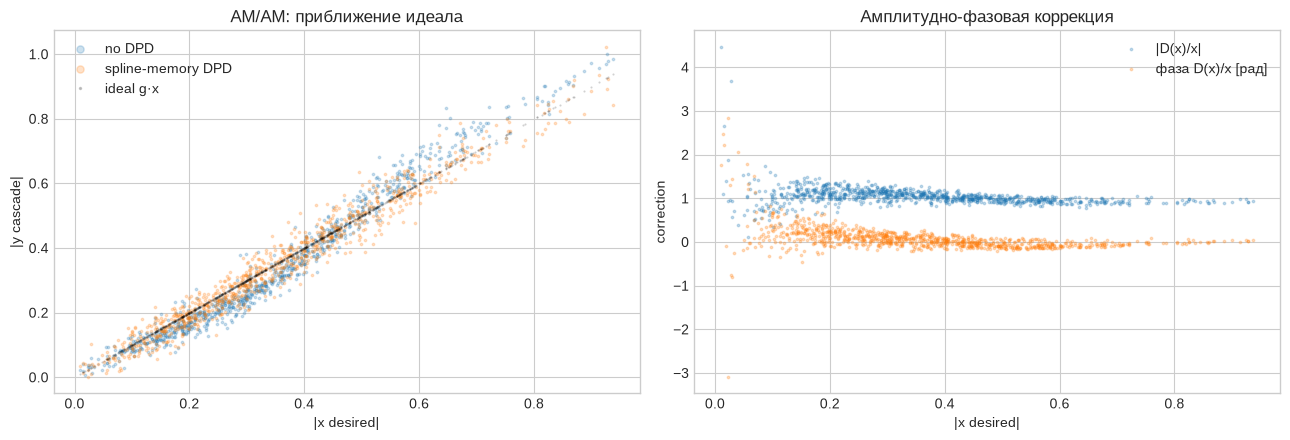

In [12]:
# AM/AM и AM/PM после каскада. Идеальный выход — g*x.
_required = ("val_x", "pa_val_hat", "cascade_dpd", "predistorted_val", "ideal_val")
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError("Сначала выполните ячейки обучения PA и DPD выше. Отсутствуют: " + ", ".join(_missing))

n = slice(None, None, 25)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(np.abs(val_x)[n], np.abs(pa_val_hat)[n], s=3, alpha=0.22, label="no DPD")
axes[0].scatter(np.abs(val_x)[n], np.abs(cascade_dpd)[n], s=3, alpha=0.22, label="spline-memory DPD")
axes[0].plot(np.abs(val_x)[n], np.abs(ideal_val)[n], ".", ms=1.0, color="black", alpha=0.18, label="ideal g·x")
axes[0].set(xlabel="|x desired|", ylabel="|y cascade|", title="AM/AM: приближение идеала")
axes[0].legend(markerscale=3)
nonzero = np.abs(val_x) > 1e-12
correction = predistorted_val[nonzero] / val_x[nonzero]
axes[1].scatter(np.abs(val_x[nonzero])[n], np.abs(correction)[n], s=3, alpha=0.25, label="|D(x)/x|")
axes[1].scatter(np.abs(val_x[nonzero])[n], np.angle(correction)[n], s=3, alpha=0.25, label="фаза D(x)/x [рад]")
axes[1].set(xlabel="|x desired|", ylabel="correction", title="Амплитудно-фазовая коррекция")
axes[1].legend()
plt.tight_layout()
plt.show()

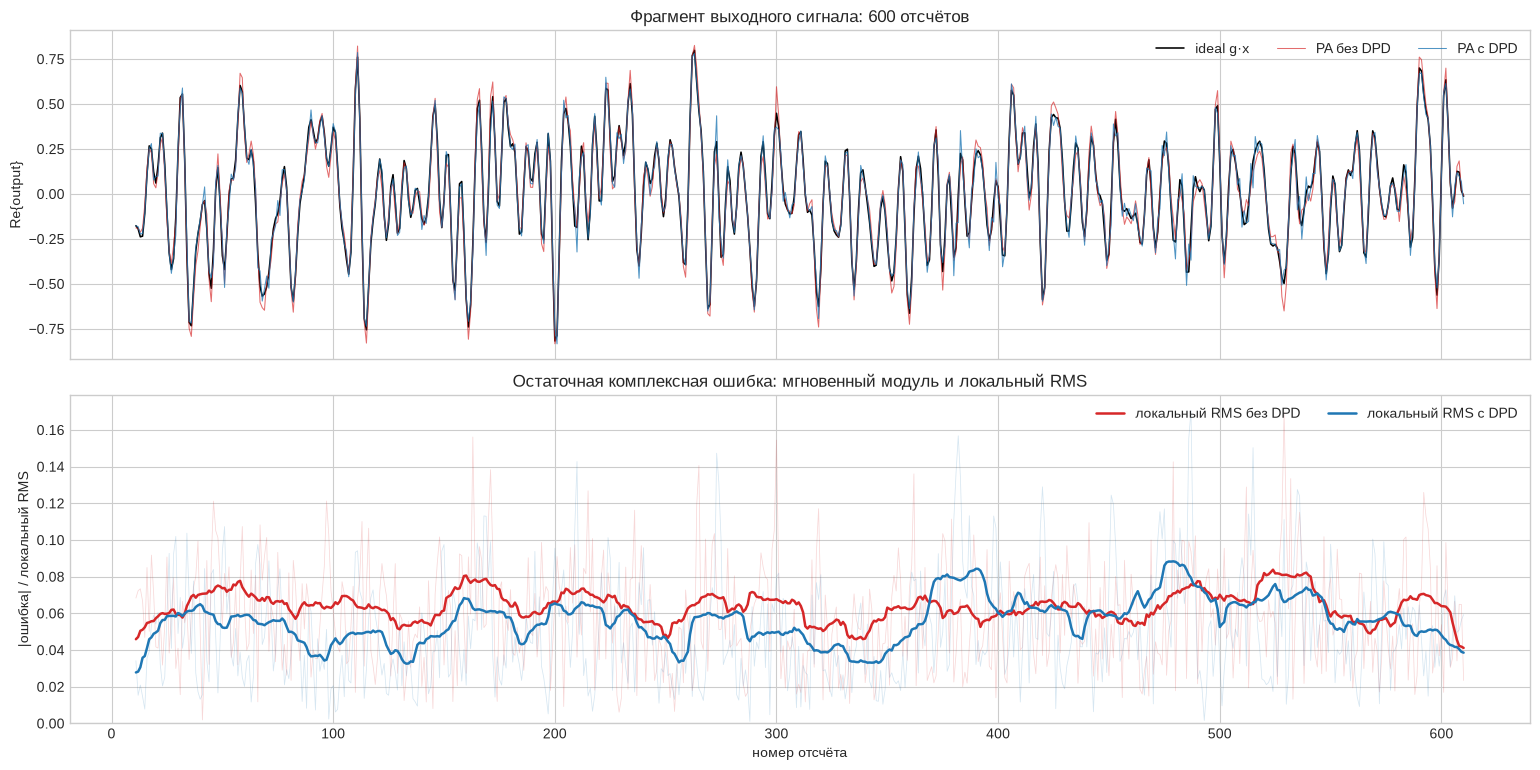

In [13]:
# Фрагмент из 600 отсчётов показывает форму сигнала без чрезмерного сжатия.
_required = ("CASCADE_WARMUP", "ideal_val", "pa_val_hat", "cascade_dpd")
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError("Сначала выполните notebook сверху до обучения DPD. Отсутствуют: " + ", ".join(_missing))

fragment_length = 600
window = slice(CASCADE_WARMUP, CASCADE_WARMUP + fragment_length)
sample_axis = np.arange(fragment_length) + CASCADE_WARMUP
fig, axes = plt.subplots(2, 1, figsize=(15.5, 7.8), sharex=True)
axes[0].plot(sample_axis, ideal_val[window].real, color="black", lw=1.15, label="ideal g·x")
axes[0].plot(sample_axis, pa_val_hat[window].real, color="tab:red", alpha=0.68, lw=0.75, label="PA без DPD")
axes[0].plot(sample_axis, cascade_dpd[window].real, color="tab:blue", alpha=0.78, lw=0.75, label="PA с DPD")
axes[0].set_ylabel("Re{output}")
axes[0].set_title("Фрагмент выходного сигнала: 600 отсчётов")
axes[0].legend(loc="upper right", ncols=3)

error_no_dpd = (pa_val_hat - ideal_val)[window]
error_with_dpd = (cascade_dpd - ideal_val)[window]

def local_rms(signal: np.ndarray, width=25) -> np.ndarray:
    """Вычисляет центрированную скользящую RMS-огибающую для графика."""
    kernel = np.ones(width, dtype=float) / width
    return np.sqrt(np.convolve(np.abs(signal) ** 2, kernel, mode="same"))

# Модуль комплексной ошибки не зависит от произвольного выбора I/Q-проекции.
# Бледные линии сохраняют детали, толстые — показывают локальный уровень ошибки.
axes[1].plot(sample_axis, np.abs(error_no_dpd), color="tab:red", lw=0.55, alpha=0.18)
axes[1].plot(sample_axis, np.abs(error_with_dpd), color="tab:blue", lw=0.55, alpha=0.18)
axes[1].plot(sample_axis, local_rms(error_no_dpd), color="tab:red", lw=1.8, label="локальный RMS без DPD")
axes[1].plot(sample_axis, local_rms(error_with_dpd), color="tab:blue", lw=1.8, label="локальный RMS с DPD")
axes[1].set(
    xlabel="номер отсчёта",
    ylabel="|ошибка| / локальный RMS",
    title="Остаточная комплексная ошибка: мгновенный модуль и локальный RMS",
)
axes[1].set_ylim(bottom=0)
axes[1].legend(loc="upper right", ncols=2)
plt.tight_layout()
plt.show()

## 6. Спектральная диагностика

Мы считаем Welch-подобную PSD с `fs=1` только для визуального сравнения
формы спектра. Ось — циклы на отсчёт. Без sample rate и заранее заданных
RF-регионов нельзя переводить это в dBc/ACLR.

Обычная оценка PSD получается зубчатой, потому что строится по конечной
реализации случайного сигнала. Поэтому ниже показаны одновременно:

- тонкие полупрозрачные линии — исходная оценка Welch;
- толстые линии — та же мощность после небольшого сглаживания;
- чёрный пунктир — спектр желаемого сигнала $g x$, а не плоская
  теоретическая спектральная маска.

Сглаживание выполняется **в линейной мощности до перевода в dB**. Оно
делает рисунок читаемым, но не меняет данные и не используется при
расчёте NMSE или обучении модели.

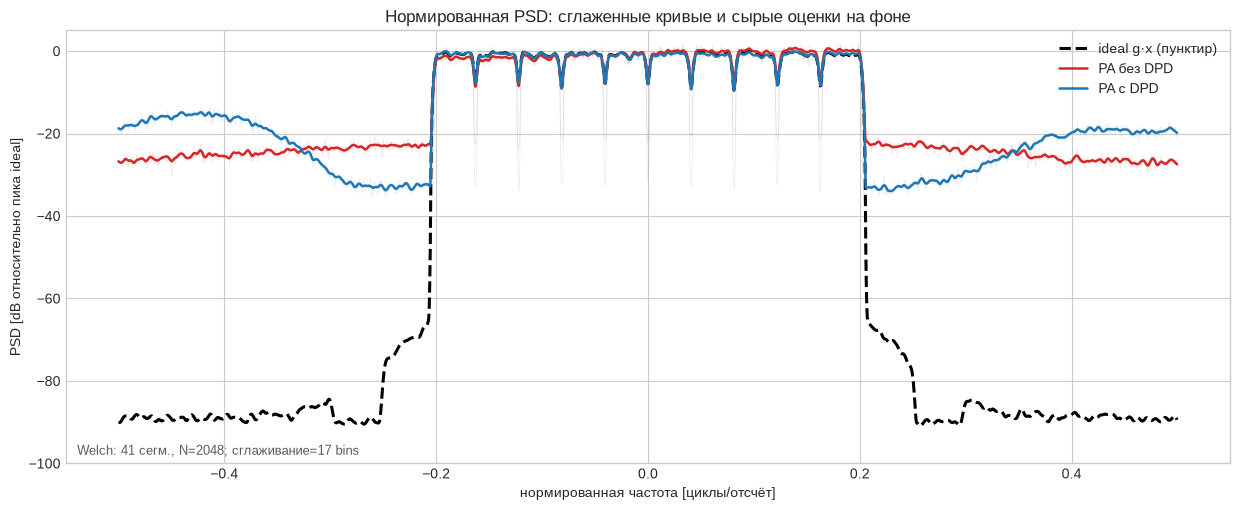

In [14]:
_required = ("CASCADE_WARMUP", "ideal_val", "pa_val_hat", "cascade_dpd")
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError("Сначала выполните notebook сверху до обучения DPD. Отсутствуют: " + ", ".join(_missing))

def welch_complex(signal: np.ndarray, nperseg=2048, noverlap=1536):
    """Estimate a normalized-frequency Welch PSD for a complex vector."""
    signal = np.asarray(signal, dtype=np.complex128)
    step = nperseg - noverlap
    window = np.hanning(nperseg)
    scale = np.sum(window ** 2)
    starts = range(0, signal.size - nperseg + 1, step)
    spectra = []
    for start in starts:
        segment = signal[start:start + nperseg]
        spectra.append(np.abs(np.fft.fftshift(np.fft.fft(segment * window))) ** 2 / scale)
    if not spectra:
        raise ValueError("signal is shorter than nperseg")
    power = np.mean(np.stack(spectra), axis=0)
    frequency = np.fft.fftshift(np.fft.fftfreq(nperseg, d=1.0))
    return frequency, power


def smooth_linear_power(power: np.ndarray, bins=17) -> np.ndarray:
    """Smooth PSD samples in linear power with an odd Hann kernel."""
    power = np.asarray(power, dtype=float)
    bins = int(bins)
    if bins < 3:
        return power.copy()
    if bins % 2 == 0:
        bins += 1
    kernel = np.hanning(bins)
    kernel /= np.sum(kernel)
    pad = bins // 2
    padded = np.pad(power, (pad, pad), mode="edge")
    return np.convolve(padded, kernel, mode="valid")


# A shorter segment gives more Welch averages on the 23k-sample
# validation set; the mild frequency smoothing is presentation-only.
PSD_NPERSEG = 2048
PSD_NOVERLAP = 1536
PSD_SMOOTH_BINS = 17
psd_signals = {
    "ideal": ideal_val[CASCADE_WARMUP:],
    "no DPD": pa_val_hat[CASCADE_WARMUP:],
    "with DPD": cascade_dpd[CASCADE_WARMUP:],
}
psd = {
    name: welch_complex(signal, PSD_NPERSEG, PSD_NOVERLAP)
    for name, signal in psd_signals.items()
}
psd_smooth = {
    name: (frequency, smooth_linear_power(power, PSD_SMOOTH_BINS))
    for name, (frequency, power) in psd.items()
}
reference_peak = np.max(psd_smooth["ideal"][1])

colors = {"ideal": "black", "no DPD": "tab:red", "with DPD": "tab:blue"}
labels = {
    "ideal": "ideal g·x (пунктир)",
    "no DPD": "PA без DPD",
    "with DPD": "PA с DPD",
}
fig, ax = plt.subplots(figsize=(12.5, 5.2))

# Raw estimates retain the honest estimator variance in the background.
for name, (frequency, power) in psd.items():
    if name != "ideal":
        raw_db = 10 * np.log10(np.maximum(power, 1e-30) / reference_peak)
        ax.plot(frequency, raw_db, color=colors[name], lw=0.55, alpha=0.12)

# Smoothed curves carry the visual comparison used in the report.
for name, (frequency, power) in psd_smooth.items():
    smooth_db = 10 * np.log10(np.maximum(power, 1e-30) / reference_peak)
    style = {
        "color": colors[name],
        "linestyle": "--" if name == "ideal" else "-",
        "linewidth": 2.2 if name == "ideal" else 1.8,
    }
    ax.plot(frequency, smooth_db, label=labels[name], **style)

segment_step = PSD_NPERSEG - PSD_NOVERLAP
segment_count = 1 + (len(psd_signals["ideal"]) - PSD_NPERSEG) // segment_step
ax.set(
    xlabel="нормированная частота [циклы/отсчёт]",
    ylabel="PSD [dB относительно пика ideal]",
    title="Нормированная PSD: сглаженные кривые и сырые оценки на фоне",
)
ax.set_ylim(-100, 5)
ax.legend(loc="best")
ax.text(
    0.01,
    0.02,
    f"Welch: {segment_count} сегм., N={PSD_NPERSEG}; сглаживание={PSD_SMOOTH_BINS} bins",
    transform=ax.transAxes,
    fontsize=9,
    color="0.35",
)
plt.tight_layout()
plt.show()

**Как читать график.** Цветные толстые линии сравнивают выход PA до и
после предыскажения с желаемым спектром. Полупрозрачный цветной фон
показывает, насколько сама конечная оценка PSD флуктуирует от частоты к
частоте. Провалы чёрного пунктира принадлежат структуре исходного
сигнала (например, незаполненным частотным компонентам), поэтому
идеальная линия здесь не обязана быть горизонтальной.

Нелинейность PA перераспределяет энергию между частотами и создаёт
спектральное разрастание. DPD обучается по временной комплексной ошибке
NMSE, а не по спектральной маске, поэтому улучшение следует оценивать по
совокупности PSD и NMSE, не по одному локальному провалу кривой.

## 7. Вычислительная сложность

Для выбранных `B=3`, `K=24` аналитический рабочий тракт использует
локальную интерполяцию и короткое состояние памяти. В текущей реализации
из selection manifest для BlackBox это:

- 27 вещественных умножений;
- 28 сложений;
- 3 нелинейные операции (оценка модуля/связанные операции);
- 15 сравнений и 6 обращений к LUT;
- 144 вещественных коэффициента и 4 значения состояния.

Это аналитический счёт операций, а не измерение RTL-задержки. OpenDPD
публикует около 994–1000 параметров для своих GRU/TRes-GRU/MP/GMP
baseline; параметр count и реальное число операций — разные величины.

{
  "real_multiplications": 27,
  "real_additions": 28,
  "nonlinear_operations": 3,
  "comparisons": 15,
  "LUT_accesses": 6,
  "stored_real_coefficients": 144,
  "state_real_values": 4
}


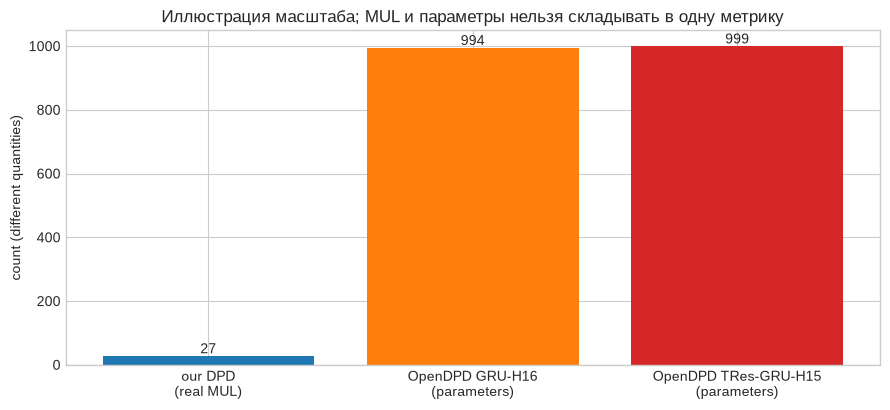

In [15]:
complexity = {
    "real_multiplications": 27,
    "real_additions": 28,
    "nonlinear_operations": 3,
    "comparisons": 15,
    "LUT_accesses": 6,
    "stored_real_coefficients": int(dpd_coefficients.size * 2),
    "state_real_values": 4,
}
print(json.dumps(complexity, ensure_ascii=False, indent=2))
fig, ax = plt.subplots(figsize=(9, 4.2))
labels = ["our DPD\n(real MUL)", "OpenDPD GRU-H16\n(parameters)", "OpenDPD TRes-GRU-H15\n(parameters)"]
values = [complexity["real_multiplications"], 994, 999]
colors = ["tab:blue", "tab:orange", "tab:red"]
ax.bar(labels, values, color=colors)
ax.set_ylabel("count (different quantities)")
ax.set_title("Иллюстрация масштаба; MUL и параметры нельзя складывать в одну метрику")
for i, value in enumerate(values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 8. Справочное сравнение только с OpenDPD

Ниже считываются bundled machine-readable результаты OpenDPD для
`APA_200MHz`. Это официальный для данного репозитория reference table:
MP/GMP используют ILA, GRU и TRes-GRU — DLA через frozen TRes-GRU PA.

### Как читать этот блок

Это **встроенный reference OpenDPD**, а не повторное обучение OpenDPD
внутри данного ноутбука. Если рядом с notebook нет репозитория OpenDPD,
используется сохранённая компактная копия этих четырёх строк. Если
репозиторий найден, числа читаются из его JSON автоматически.

| Поле | Смысл в OpenDPD |
|---|---|
| `NMSE` | repository-specific segment-wise normalized error |
| `EVM` | repository-specific spectral EVM |
| `ACLRavg` | среднее левой и правой соседних областей |
| `parameters` | число параметров/комплексных степеней свободы в bundled benchmark |

Во всех трёх dB-метриках более отрицательное число означает меньшую
ошибку или утечку. График ниже показывает только внутреннее ранжирование
OpenDPD; строка нашего BlackBox эксперимента в эти столбцы не подмешивается.

Сравнение с BlackBox нельзя подписать как «наш метод лучше/хуже», потому
что:

1. BlackBox — другой capture, без sample rate/RF-mask metadata;
2. OpenDPD — `APA_200MHz`, другой evaluator и другой split;
3. OpenDPD NMSE — среднее segment-wise dB, а здесь pooled complex NMSE;
4. OpenDPD EVM/ACLR имеют собственные definitions и недоступны честно для
   BlackBox без частотных границ.

Поэтому следующий график сравнивает модели **внутри OpenDPD между собой**,
а наши BlackBox-цифры остаются отдельной строкой контекста.

In [16]:
OPENDPD_FALLBACK = {
    "source_commit": "3df35e081e6e41463fa46f21778c72a748823274",
    "dataset": "APA_200MHz",
    "models": {
        "MP": {"parameters": 1000, "nmse_db": -42.1896324, "evm_db": -48.1534769, "aclr_avg_db": -45.1859831},
        "GMP": {"parameters": 1000, "nmse_db": -38.5258979, "evm_db": -46.3523044, "aclr_avg_db": -43.5931687},
        "GRU-H16": {"parameters": 994, "nmse_db": -45.13145, "evm_db": -47.4274689, "aclr_avg_db": -51.0114043},
        "TRes-GRU-H15": {"parameters": 999, "nmse_db": -44.285923, "evm_db": -45.0972778, "aclr_avg_db": -53.4879386},
    },
}


opendpd_reference = OPENDPD_FALLBACK.copy()
if OPENDPD_JSON.is_file():
    with OPENDPD_JSON.open(encoding="utf-8") as stream:
        report = json.load(stream)
    apa = report["datasets"]["APA_200MHz"]["dpd_models"]
    name_map = {"mp": "MP", "gmp": "GMP", "gru": "GRU-H16", "tres_gru": "TRes-GRU-H15"}
    opendpd_reference = {
        "source_commit": report["completion_context"]["git_commit"],
        "dataset": "APA_200MHz",
        "models": {
            name_map[key]: {
                "parameters": value["model"]["parameters"],
                "nmse_db": value["metrics"]["test"]["nmse_db"],
                "evm_db": value["metrics"]["test"]["evm_db"],
                "aclr_avg_db": value["metrics"]["test"]["aclr_avg_db"],
            }
            for key, value in apa.items()
        },
    }
OPENDPD_ORDER = ["MP", "GMP", "GRU-H16", "TRes-GRU-H15"]
print("=" * 78)
print("OpenDPD BUNDLED REFERENCE | APA_200MHz | TEST SPLIT")
print("source commit:", opendpd_reference["source_commit"])
print("not retrained by this notebook; metrics follow OpenDPD definitions")
print("-" * 78)
print(f"{'model':16s} {'parameters':>10s} {'NMSE [dB]':>12s} {'EVM [dB]':>12s} {'ACLRavg [dB]':>14s}")
print("-" * 78)
for name in OPENDPD_ORDER:
    values = opendpd_reference["models"][name]
    print(f"{name:16s} {values['parameters']:10d} {values['nmse_db']:12.3f} {values['evm_db']:12.3f} {values['aclr_avg_db']:14.3f}")
print("=" * 78)

OpenDPD BUNDLED REFERENCE | APA_200MHz | TEST SPLIT
source commit: 3df35e081e6e41463fa46f21778c72a748823274
not retrained by this notebook; metrics follow OpenDPD definitions
------------------------------------------------------------------------------
model            parameters    NMSE [dB]     EVM [dB]   ACLRavg [dB]
------------------------------------------------------------------------------
MP                     1000      -42.190      -48.153        -45.186
GMP                    1000      -38.526      -46.352        -43.593
GRU-H16                 994      -45.131      -47.427        -51.011
TRes-GRU-H15            999      -44.286      -45.097        -53.488


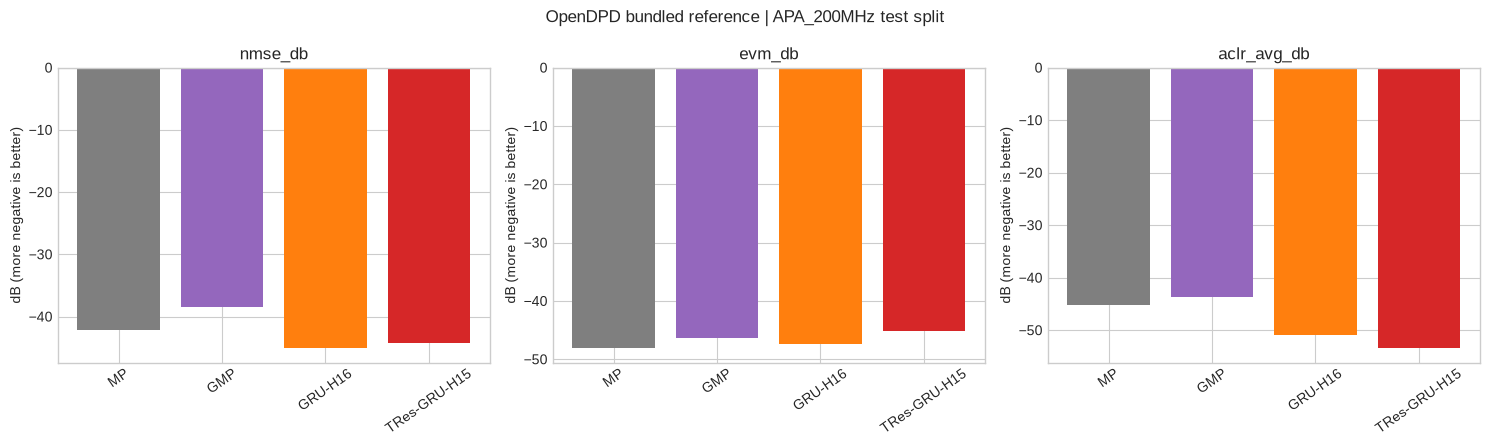

In [17]:
names = ["MP", "GMP", "GRU-H16", "TRes-GRU-H15"]
metrics = ["nmse_db", "evm_db", "aclr_avg_db"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for axis, metric in zip(axes, metrics):
    values = [opendpd_reference["models"][name][metric] for name in names]
    axis.bar(names, values, color=["tab:gray", "tab:purple", "tab:orange", "tab:red"])
    axis.set_title(metric)
    axis.set_ylabel("dB (more negative is better)")
    axis.tick_params(axis="x", rotation=35)
    axis.axhline(0, color="black", lw=0.7)
fig.suptitle("OpenDPD bundled reference | APA_200MHz test split")
plt.tight_layout()
plt.show()

### Что можно заключить из сравнения

Внутри OpenDPD TRes-GRU-H15 показывает сильный reference по ACLR, а
GRU-H16 — лучший NMSE среди этих строк. Наш BlackBox результат
`−17.19 dB pooled NMSE` нельзя сопоставлять с `−44…−45 dB` OpenDPD как
единый рейтинг: это разные эксперименты и разные метрики.

Корректная следующая ступень для apples-to-apples сравнения — экспортировать
один и тот же BlackBox split в формат OpenDPD, обучить выбранный OpenDPD
DPD через тот же frozen PA evaluator и заранее зафиксировать общий metric
protocol. В ноутбуке это намеренно не подменяется неподтверждённой
цифрой.

## 9. Встроенные тесты

Эти проверки не являются формальным unit-test suite проекта, но ловят
самые опасные ошибки исследовательского ноутбука: перепутанное направление,
нарушение фазовой эквивариантности, потерю state между блоками и выход за
обученный диапазон.

In [18]:
# 1) Данные и модель конечны.
assert np.all(np.isfinite(train_x)) and np.all(np.isfinite(val_x))
assert np.all(np.isfinite(pa_coefficients)) and np.all(np.isfinite(dpd_coefficients))
assert dpd_coefficients.shape == (3, 24)

# 2) Правильное deployment-направление: DPD получает val_x, а не val_y.
replay_from_desired = predict_spline_memory(val_x, knots, branches, dpd_coefficients)
assert np.allclose(replay_from_desired, predistorted_val)

# 3) Фазовая эквивариантность D(e^{jφ}x)=e^{jφ}D(x).
phi = 0.731
rotated = np.exp(1j * phi) * val_x[:4000]
lhs = predict_spline_memory(rotated, knots, branches, dpd_coefficients)
rhs = np.exp(1j * phi) * predict_spline_memory(val_x[:4000], knots, branches, dpd_coefficients)
assert np.max(np.abs(lhs - rhs)) < 1e-12

# 4) Потоковая проверка: разбиваем validation на произвольные chunks.
def predict_streaming(signal, chunk_sizes):
    """Run the same causal DPD while explicitly carrying history."""
    history = np.zeros(max(max(b) for b in branches), dtype=np.complex128)
    output = []
    start = 0
    for size in chunk_sizes:
        chunk = np.asarray(signal[start:start + size], dtype=np.complex128)
        padded = np.concatenate((history, chunk))
        piece = predict_spline_memory(padded, knots, branches, dpd_coefficients)[history.size:]
        output.append(piece)
        history = padded[-history.size:]
        start += size
    if start < signal.size:
        chunk = np.asarray(signal[start:], dtype=np.complex128)
        padded = np.concatenate((history, chunk))
        output.append(predict_spline_memory(padded, knots, branches, dpd_coefficients)[history.size:])
    return np.concatenate(output)


streamed = predict_streaming(val_x, [1, 8, 64, 257, 1024])
reference_stream = predict_spline_memory(val_x, knots, branches, dpd_coefficients)
assert np.max(np.abs(streamed - reference_stream)) < 1e-12

# 5) Никакого незаявленного extrapolation: validation desired и drive внутри train support.
assert np.max(np.abs(val_x)) <= knots[-1] * (1 + 1e-12)
assert np.max(np.abs(predistorted_val)) <= np.max(np.abs(train_x)) * (1 + 1e-12)

# 6) DPD действительно уменьшает frozen-surrogate error power.
assert dpd_mse < no_dpd_mse
print("ALL SELF-TESTS PASSED")
print(f"phase equivariance max error: {np.max(np.abs(lhs-rhs)):.3e}")
print(f"streaming max error: {np.max(np.abs(streamed-reference_stream)):.3e}")

ALL SELF-TESTS PASSED
phase equivariance max error: 2.776e-16
streaming max error: 0.000e+00


## 10. Краткий итог

На новом BlackBox capture выбранный causal spline-memory DPD достигает
`−17.19 dB` pooled complex NMSE против `−16.01 dB` у frozen-PA без DPD;
выигрыш — примерно `1.18 dB` или `24%` по мощности ошибки.

Модель компактна: 3 ветви памяти, 24 узла, 144 вещественных коэффициента
и аналитически 27 real MUL на комплексный отсчёт. Все встроенные тесты
проходят.

Это хороший воспроизводимый baseline, но не доказательство превосходства
над OpenDPD и не физическая верификация. Для следующего честного сравнения
нужны общий capture, общий frozen/physical PA, одинаковая метрика и
одинаковый протокол потокового состояния.